<a href="https://colab.research.google.com/github/One-G-Row/ATF_Labs/blob/main/03_transformer_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1.3: The Transformer & Attention Mechanisms

## Learning Objectives
- Understand how attention works
- Learn about the Transformer architecture
- See how context understanding happens
- Build attention mechanisms for digital twins

## Key Insight
> 'How Attention helps the AI understand context (e.g., Bank = River).'

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
print('✅ Libraries loaded!')

✅ Libraries loaded!


## Part 1: Understanding Attention

### The Context Problem

In [2]:
# Example: Context-dependent meaning
sentences = [
    'I went to the bank to deposit money',
    'I sat on the bank of the river',
    'The bank was steep and grassy'
]

print('Same word, different meanings:')
for i, sent in enumerate(sentences, 1):
    print(f'{i}. {sent}')

# Question: How does the model know which 'bank'?

Same word, different meanings:
1. I went to the bank to deposit money
2. I sat on the bank of the river
3. The bank was steep and grassy


### 1.1 Self-Attention Mechanism

In [3]:
class SimpleAttention:
    '''Simple self-attention implementation.'''

    def __init__(self, embedding_dim):
        self.embedding_dim = embedding_dim
        # Query, Key, Value matrices
        self.W_q = np.random.randn(embedding_dim, embedding_dim) * 0.1
        self.W_k = np.random.randn(embedding_dim, embedding_dim) * 0.1
        self.W_v = np.random.randn(embedding_dim, embedding_dim) * 0.1

    def attention_scores(self, embeddings):
        '''Calculate attention scores.'''
        # Query, Key, Value projections
        Q = embeddings @ self.W_q
        K = embeddings @ self.W_k
        V = embeddings @ self.W_v

        # Attention scores
        scores = Q @ K.T / np.sqrt(self.embedding_dim)

        # Softmax
        scores = np.exp(scores) / np.exp(scores).sum(axis=1, keepdims=True)

        return scores, V

    def forward(self, embeddings):
        '''Apply attention.'''
        scores, V = self.attention_scores(embeddings)
        output = scores @ V
        return output, scores

# Test with simple embeddings
seq_length = 5
emb_dim = 8
embeddings = np.random.randn(seq_length, emb_dim)

attention = SimpleAttention(emb_dim)
output, scores = attention.forward(embeddings)

print(f'Input shape: {embeddings.shape}')
print(f'Output shape: {output.shape}')
print(f'Attention scores shape: {scores.shape}')

Input shape: (5, 8)
Output shape: (5, 8)
Attention scores shape: (5, 5)


### 🎯 Exercise 1.1 (Intermediate): Visualize Attention

**Task**: Visualize the attention pattern as a heatmap.

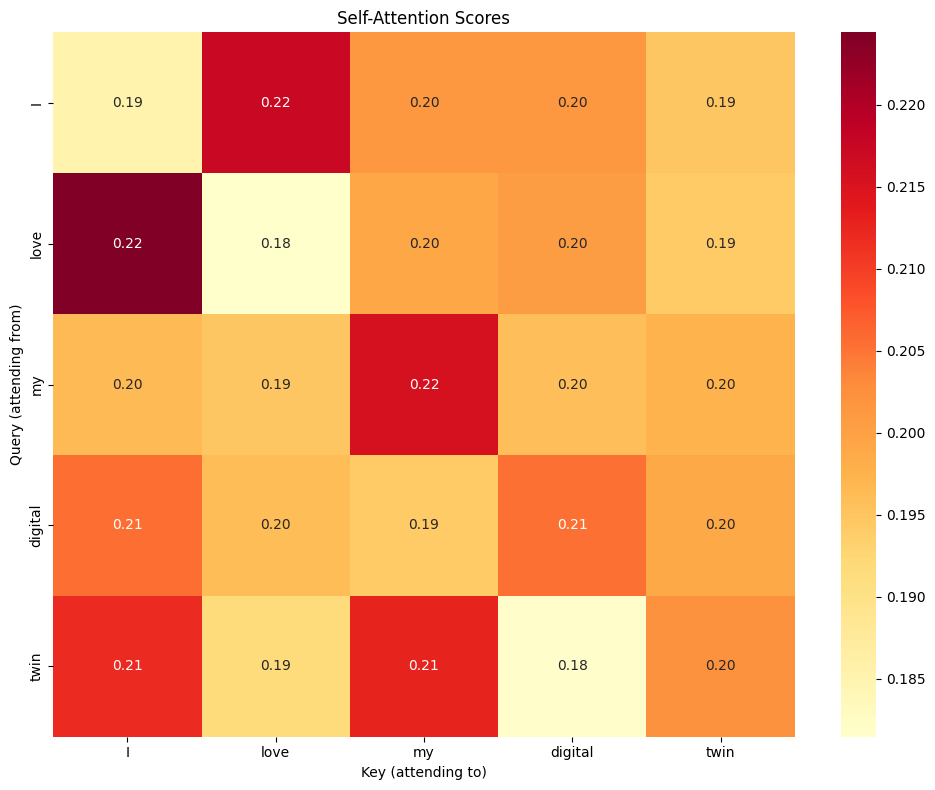

In [8]:
# YOUR CODE HERE
np.random.seed(42)

def visualize_attention(scores, words):
    '''Visualize attention scores.'''
    plt.figure(figsize=(10, 8))
    sns.heatmap(scores, annot=True, fmt='.2f',
                xticklabels=words, yticklabels=words,
                cmap='YlOrRd')
    plt.title('Self-Attention Scores')
    plt.xlabel('Key (attending to)')
    plt.ylabel('Query (attending from)')
    plt.tight_layout()
    plt.show()

# Test with example
words = ['I', 'love', 'my', 'digital', 'twin']
# Create and visualize
embeddings_dim = 8
embeddings = np.random.randn(len(words), embeddings_dim)
attention = SimpleAttention(embeddings_dim)
output, scores = attention.forward(embeddings)
visualize_attention(scores, words)
